In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"minervac1111","key":"24cf9e72da0c057d0861af82f54b4157"}'}

In [2]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

# Kaggle kütüphanesini yükle
!pip install kaggle -q

# Veri setini indir
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 179MB/s]



In [3]:
import zipfile

with zipfile.ZipFile('/content/breast-ultrasound-images-dataset.zip', 'r') as z:
    z.extractall('/content/BUSI')

# Klasör yapısını görelim
import os
for root, dirs, files in os.walk('/content/BUSI'):
    level = root.replace('/content/BUSI', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{len(files)} dosya')

BUSI/
  0 dosya
  Dataset_BUSI_with_GT/
    0 dosya
    malignant/
    normal/
    benign/


In [6]:
import os
from pathlib import Path

data_dir = Path('/content/BUSI/Dataset_BUSI_with_GT')

for split in ['benign', 'malignant', 'normal']:
    folder = data_dir / split
    images = [f for f in os.listdir(folder) if 'mask' not in f and f.endswith('.png')]
    masks = [f for f in os.listdir(folder) if 'mask' in f and f.endswith('.png')]
    print(f'{split}: {len(images)} görüntü, {len(masks)} maske')


benign: 437 görüntü, 454 maske
malignant: 210 görüntü, 211 maske
normal: 133 görüntü, 133 maske


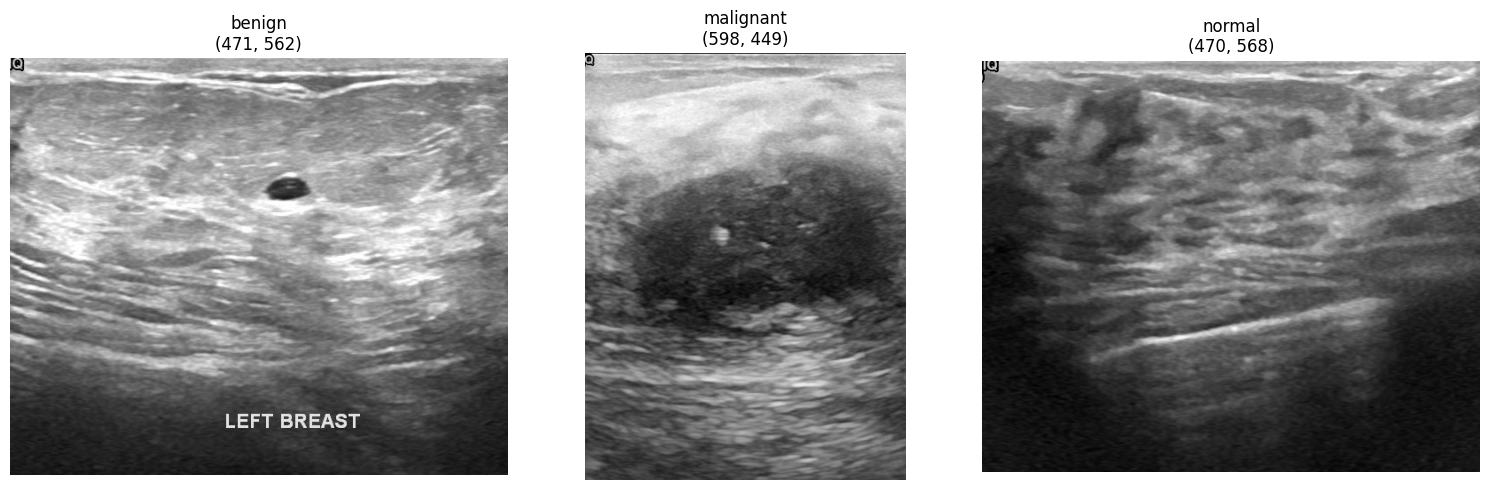

In [7]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

data_dir = Path('/content/BUSI/Dataset_BUSI_with_GT')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(['benign', 'malignant', 'normal']):
    folder = data_dir / category
    images = sorted([f for f in os.listdir(folder)
                     if 'mask' not in f and f.endswith('.png')])

    img = cv2.imread(str(folder / images[0]), cv2.IMREAD_GRAYSCALE)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{category}\n{img.shape}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [9]:
import cv2
import numpy as np
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage import img_as_float, img_as_ubyte

def add_speckle_noise(image, variance=0.05):
    """Kontrollü speckle noise ekle — ground truth için"""
    img_float = img_as_float(image)
    noise = np.random.rayleigh(np.sqrt(variance), img_float.shape)
    noisy = img_float * noise
    return np.clip(noisy, 0, 1)

def non_local_means(image):
    """Non-Local Means denoising"""
    img_float = img_as_float(image)
    sigma_est = estimate_sigma(img_float)
    denoised = denoise_nl_means(img_float,
                                h=1.15 * sigma_est,
                                fast_mode=True,
                                patch_size=5,
                                patch_distance=3)
    return denoised

def median_filter(image, kernel_size=3):
    """Basit median filter — baseline"""
    return cv2.medianBlur(image, kernel_size)

def gaussian_filter(image, kernel_size=5):
    """Gaussian filter — en basit baseline"""
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

print("Metodlar hazır.")

Metodlar hazır.


In [10]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np

def evaluate(original, denoised):
    """PSNR ve SSIM hesapla"""
    original = np.clip(original, 0, 1)
    denoised = np.clip(denoised, 0, 1)

    p = psnr(original, denoised, data_range=1.0)
    s = ssim(original, denoised, data_range=1.0)
    return {'PSNR': round(p, 3), 'SSIM': round(s, 3)}

print("Metrikler hazır.")

Metrikler hazır.


Noisy                → PSNR:   7.61 dB  |  SSIM: 0.167
Non-Local Means      → PSNR:   7.63 dB  |  SSIM: 0.214
Median Filter        → PSNR:   7.51 dB  |  SSIM: 0.213
Gaussian Filter      → PSNR:   7.71 dB  |  SSIM: 0.248


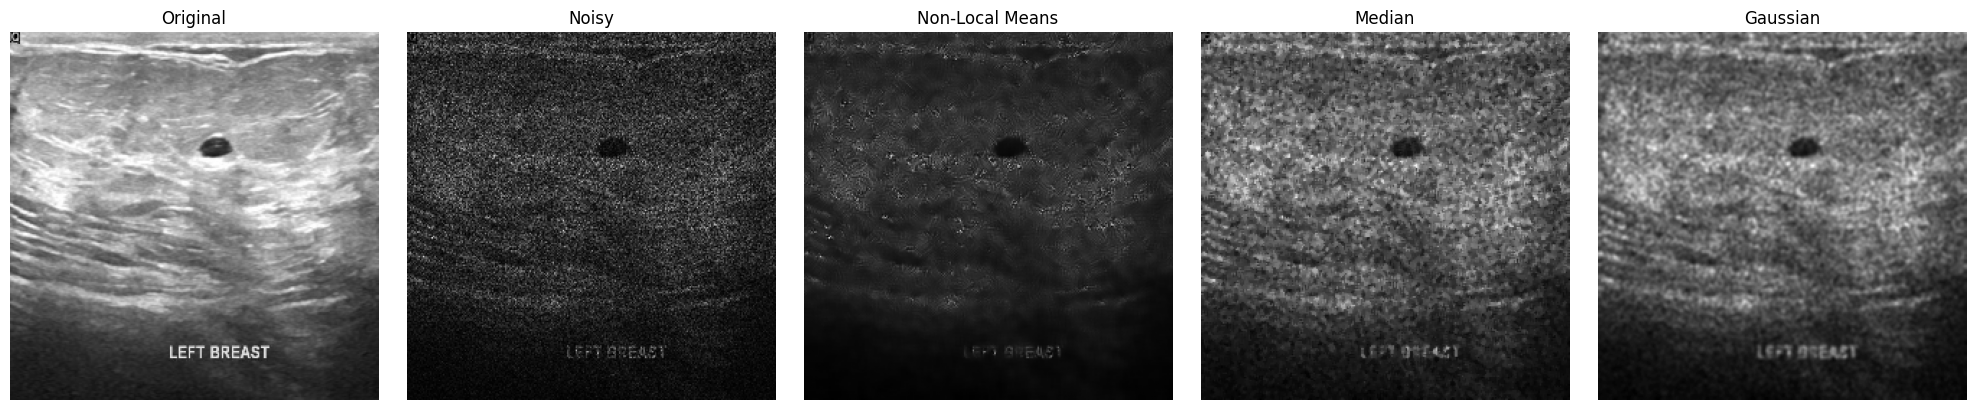

In [15]:
from pathlib import Path
import cv2
import numpy as np
from skimage import img_as_float
import matplotlib.pyplot as plt

# Bir görüntü yükle
data_dir = Path('/content/BUSI/Dataset_BUSI_with_GT')
sample_path = sorted([f for f in (data_dir / 'benign').iterdir()
                      if 'mask' not in f.name and f.suffix == '.png'])[0]

original = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
original = cv2.resize(original, (256, 256))
original_float = img_as_float(original)

# Noise ekle
noisy_float = add_speckle_noise(original_float, variance=0.05)
noisy_uint8 = (noisy_float * 255).astype(np.uint8)

# Yöntemleri uygula
nlm = non_local_means((noisy_float * 255).astype(np.uint8))
med = img_as_float(median_filter(noisy_uint8))
gauss = img_as_float(gaussian_filter(noisy_uint8))

# Metrikleri hesapla
results = {
    'Noisy':        evaluate(original_float, noisy_float),
    'Non-Local Means': evaluate(original_float, nlm),
    'Median Filter':   evaluate(original_float, med),
    'Gaussian Filter': evaluate(original_float, gauss),
}

for method, scores in results.items():
    print(f"{method:20s} → PSNR: {scores['PSNR']:6.2f} dB  |  SSIM: {scores['SSIM']:.3f}")

# Görsel karşılaştırma
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ['Original', 'Noisy', 'Non-Local Means', 'Median', 'Gaussian']
imgs = [original_float, noisy_float, nlm, med, gauss]

for ax, title, img in zip(axes, titles, imgs):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
def add_speckle_noise(image, variance=0.01):
    """Daha gerçekçi speckle noise"""
    img_float = img_as_float(image)
    noise = np.random.rayleigh(np.sqrt(variance), img_float.shape)
    noisy = img_float * noise
    # Normalize et — aralığı koru
    noisy = (noisy - noisy.min()) / (noisy.max() - noisy.min())
    return noisy

def non_local_means(image):
    img_float = img_as_float(image)
    sigma_est = estimate_sigma(img_float)
    denoised = denoise_nl_means(img_float,
                                h=1.15 * sigma_est,
                                fast_mode=True,
                                patch_size=5,
                                patch_distance=3)
    # Normalize
    denoised = (denoised - denoised.min()) / (denoised.max() - denoised.min())
    return denoised

def median_filter(image, kernel_size=3):
    result = cv2.medianBlur(image, kernel_size)
    result_float = img_as_float(result)
    return (result_float - result_float.min()) / (result_float.max() - result_float.min())

def gaussian_filter(image, kernel_size=5):
    result = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    result_float = img_as_float(result)
    return (result_float - result_float.min()) / (result_float.max() - result_float.min())

print("Metodlar güncellendi.")

Metodlar güncellendi.


In [14]:
def add_speckle_noise(image, variance=0.004):
    """Hafif speckle noise — daha gerçekçi"""
    img_float = img_as_float(image)
    noise = np.random.rayleigh(np.sqrt(variance), img_float.shape)
    noisy = img_float * noise
    return np.clip(noisy, 0, 1)

def non_local_means(image):
    img_float = img_as_float(image)
    sigma_est = estimate_sigma(img_float)
    denoised = denoise_nl_means(img_float,
                                h=1.15 * sigma_est,
                                fast_mode=True,
                                patch_size=5,
                                patch_distance=3)
    return np.clip(denoised, 0, 1)

def median_filter(image, kernel_size=3):
    result = cv2.medianBlur(image, kernel_size)
    return np.clip(img_as_float(result), 0, 1)

def gaussian_filter(image, kernel_size=5):
    result = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    return np.clip(img_as_float(result), 0, 1)

print("Metodlar güncellendi.")

Metodlar güncellendi.


In [16]:
def add_speckle_noise(image, sigma=0.05):
    """Additive Gaussian noise — kontrollü test için"""
    img_float = img_as_float(image)
    noise = np.random.normal(0, sigma, img_float.shape)
    noisy = img_float + noise
    return np.clip(noisy, 0, 1)

def non_local_means(noisy_float):
    sigma_est = estimate_sigma(noisy_float)
    denoised = denoise_nl_means(noisy_float,
                                h=1.15 * sigma_est,
                                fast_mode=True,
                                patch_size=5,
                                patch_distance=3)
    return np.clip(denoised, 0, 1)

def median_filter(noisy_float, kernel_size=3):
    noisy_uint8 = (noisy_float * 255).astype(np.uint8)
    result = cv2.medianBlur(noisy_uint8, kernel_size)
    return np.clip(img_as_float(result), 0, 1)

def gaussian_filter(noisy_float, kernel_size=5):
    noisy_uint8 = (noisy_float * 255).astype(np.uint8)
    result = cv2.GaussianBlur(noisy_uint8, (kernel_size, kernel_size), 0)
    return np.clip(img_as_float(result), 0, 1)

print("Metodlar güncellendi.")

Metodlar güncellendi.


Noisy                → PSNR:  26.07 dB  |  SSIM: 0.702
Non-Local Means      → PSNR:  30.49 dB  |  SSIM: 0.840
Median Filter        → PSNR:  27.46 dB  |  SSIM: 0.815
Gaussian Filter      → PSNR:  27.52 dB  |  SSIM: 0.834


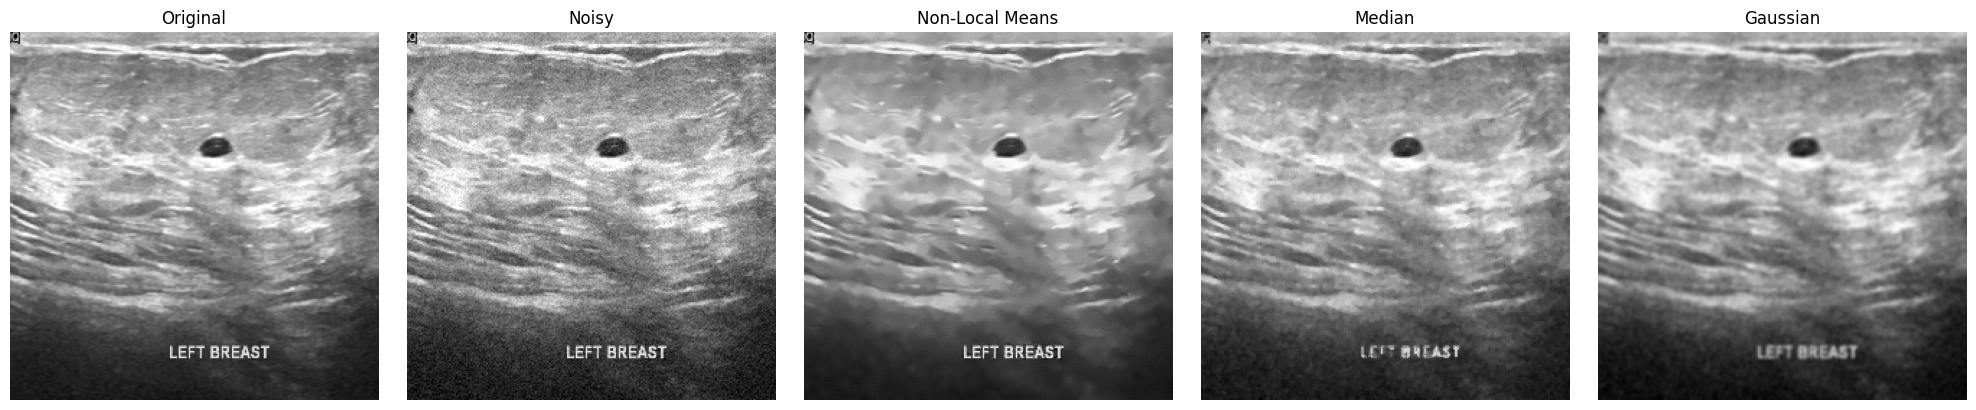

In [17]:
# Noise ekle
noisy_float = add_speckle_noise(original_float, sigma=0.05)

# Yöntemleri uygula — direkt float gönder
nlm   = non_local_means(noisy_float)
med   = median_filter(noisy_float)
gauss = gaussian_filter(noisy_float)

# Metrikleri hesapla
results = {
    'Noisy':           evaluate(original_float, noisy_float),
    'Non-Local Means': evaluate(original_float, nlm),
    'Median Filter':   evaluate(original_float, med),
    'Gaussian Filter': evaluate(original_float, gauss),
}

for method, scores in results.items():
    print(f"{method:20s} → PSNR: {scores['PSNR']:6.2f} dB  |  SSIM: {scores['SSIM']:.3f}")

# Görsel
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ['Original', 'Noisy', 'Non-Local Means', 'Median', 'Gaussian']
imgs   = [original_float, noisy_float, nlm, med, gauss]

for ax, title, img in zip(axes, titles, imgs):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [21]:
from tqdm import tqdm

def run_benchmark(data_dir, categories=['benign', 'malignant', 'normal'], sigma=0.05):
    all_results = {
        'Noisy': [], 'Non-Local Means': [],
        'Median Filter': [], 'Gaussian Filter': []
    }

    for category in categories:
        folder = Path(data_dir) / category
        images = sorted([f for f in folder.iterdir()
                        if 'mask' not in f.name and f.suffix == '.png'])

        print(f"\n{category} işleniyor ({len(images)} görüntü)...")

        for img_path in tqdm(images):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (256, 256))
            original = img_as_float(img)
            noisy = add_speckle_noise(original, sigma=sigma)

            methods = {
                'Noisy':           noisy,
                'Non-Local Means': non_local_means(noisy),
                'Median Filter':   median_filter(noisy),
                'Gaussian Filter': gaussian_filter(noisy),
            }

            for name, result in methods.items():
                scores = evaluate(original, result)
                all_results[name].append(scores)

    # Ortalama hesapla
    print("\n--- BENCHMARK SONUÇLARI ---")
    print(f"{'Method':20s} | {'PSNR (mean)':>12} | {'SSIM (mean)':>12}")
    print("-" * 50)
    for method, scores_list in all_results.items():
        avg_psnr = np.mean([s['PSNR'] for s in scores_list])
        avg_ssim = np.mean([s['SSIM'] for s in scores_list])
        print(f"{method:20s} | {avg_psnr:>11.2f} dB | {avg_ssim:>12.3f}")

    return all_results

all_results = run_benchmark('/content/BUSI/Dataset_BUSI_with_GT')


benign işleniyor (437 görüntü)...


100%|██████████| 437/437 [00:35<00:00, 12.34it/s]



malignant işleniyor (210 görüntü)...


100%|██████████| 210/210 [00:17<00:00, 11.77it/s]



normal işleniyor (133 görüntü)...


100%|██████████| 133/133 [00:11<00:00, 11.52it/s]


--- BENCHMARK SONUÇLARI ---
Method               |  PSNR (mean) |  SSIM (mean)
--------------------------------------------------
Noisy                |       26.25 dB |        0.649
Non-Local Means      |       31.47 dB |        0.827
Median Filter        |       29.71 dB |        0.810
Gaussian Filter      |       29.99 dB |        0.836


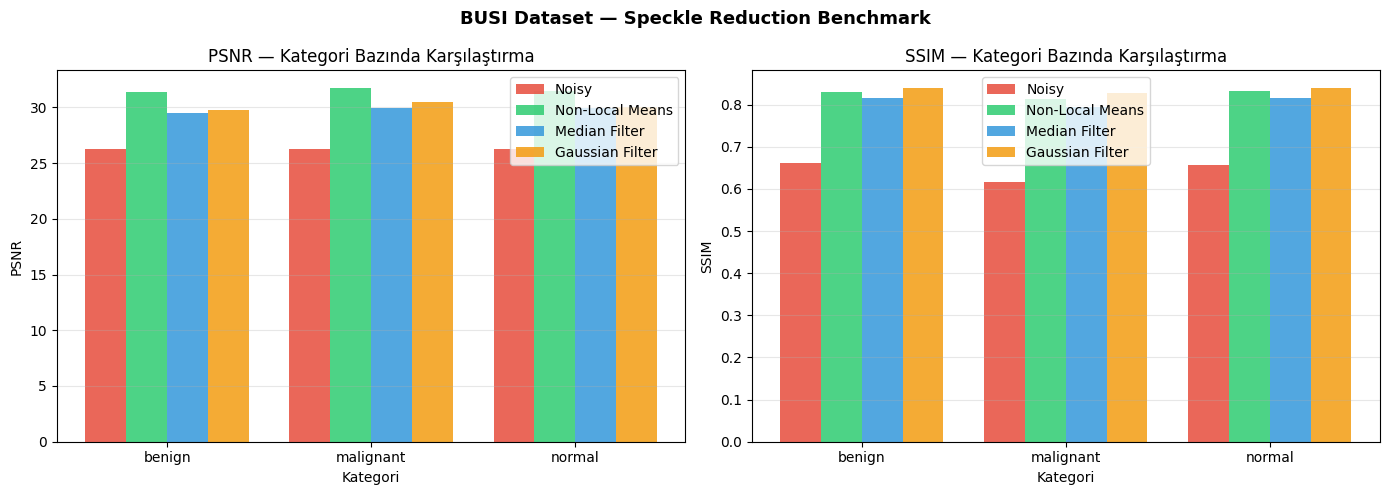

Grafik kaydedildi.


In [22]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['benign', 'malignant', 'normal']
methods = ['Noisy', 'Non-Local Means', 'Median Filter', 'Gaussian Filter']
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

# Kategori bazında ortalamalar
def category_means(results_list, categories, images_per_cat):
    """Her kategori için ayrı ortalama"""
    splits = {}
    idx = 0
    counts = {'benign': 437, 'malignant': 210, 'normal': 133}
    for cat in categories:
        n = counts[cat]
        splits[cat] = results_list[idx:idx+n]
        idx += n
    return splits

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['PSNR', 'SSIM']

for ax, metric in zip(axes, metrics):
    x = np.arange(len(categories))
    width = 0.2

    for i, (method, color) in enumerate(zip(methods, colors)):
        scores = all_results[method]
        counts = {'benign': 437, 'malignant': 210, 'normal': 133}

        cat_means = []
        idx = 0
        for cat in categories:
            n = counts[cat]
            cat_scores = [s[metric] for s in scores[idx:idx+n]]
            cat_means.append(np.mean(cat_scores))
            idx += n

        ax.bar(x + i * width, cat_means, width,
               label=method, color=color, alpha=0.85)

    ax.set_xlabel('Kategori')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Kategori Bazında Karşılaştırma')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('BUSI Dataset — Speckle Reduction Benchmark',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi.")